<a href="https://colab.research.google.com/github/AKSHAYA-1412/Python-SQL-Training/blob/main/Fraud_Detection_Logistic_Regeression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
# Dataset
data = [
[1,1200,2,1,500,1,1,0,1],
[2,50,24,0,200,0,0,1,0],
[3,5000,1,1,450,1,1,0,1],
[4,200,48,0,300,0,0,1,0],
[5,1500,3,1,700,1,0,0,1],
[6,75,72,0,150,0,0,1,0],
[7,3200,2,1,400,1,1,0,1],
[8,40,96,0,100,0,0,1,0],
[9,2100,5,1,600,1,1,0,1],
[10,60,120,0,120,0,0,1,0]
]

In [ ]:
columns = ["TransactionID","Amount","TimeSinceLastTxn","LocationChange",
           "AvgTxnAmount","IsForeign","IsHighRiskCountry","CardPresent","IsFraud"]

df = pd.DataFrame(data, columns=columns)

# Features & Target
X = df.drop(["TransactionID", "IsFraud"], axis=1)
y = df["IsFraud"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))




              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



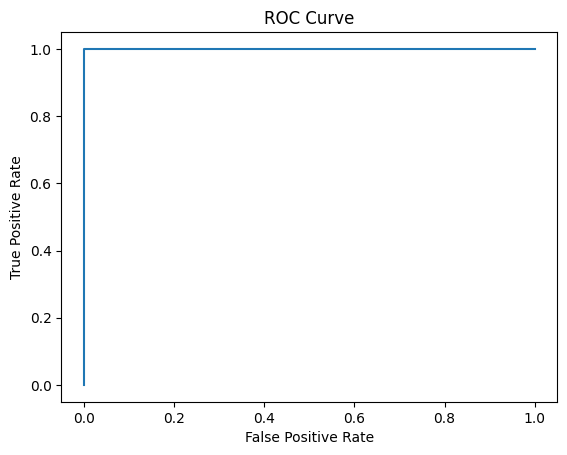

In [ ]:
# =========================
# 📊 GRAPH 1: ROC Curve
# =========================
y_prob = model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

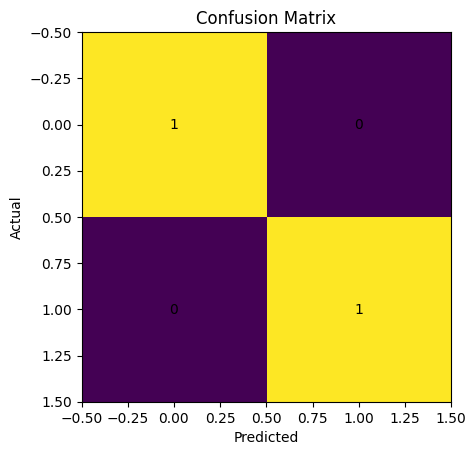

In [ ]:
# =========================
# 📊 GRAPH 2: Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add numbers inside boxes
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()



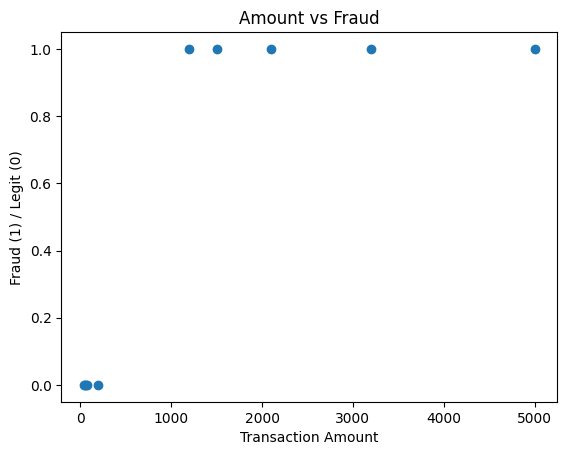

In [ ]:
# =========================
# 📊 GRAPH 3: Amount vs Fraud
# =========================
plt.figure()
plt.scatter(df["Amount"], df["IsFraud"])
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud (1) / Legit (0)")
plt.title("Amount vs Fraud")
plt.show()